In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import backend as K
from sklearn import preprocessing
from importlib import reload

%matplotlib inline
%config InlineBackend.figure_format='retina'

## Load data

In [1]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/test_mag_24.5/'
root_dir_v2 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/test_mag_26.5/'

## Load transformations of ellipticities

### for inputs

In [3]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)

## for outputs

data_gen = pd.read_csv('/sps/lsst/users/barcelin/data/dc2_test/training_2/1_img_data.csv')
ell_1_test = np.array(data_gen['e1'])
ell_2_test = np.array(data_gen['e2'])
shear_1_test = np.array(data_gen['shear_1'])
shear_2_test = np.array(data_gen['shear_2'])
convergence_test = np.array(data_gen['convergence'])

ellipticity_1_test = calc_lensed_ellipticity_1(ell_1_test, ell_2_test, shear_1_test, shear_2_test, convergence_test)
ellipticity_2_test = calc_lensed_ellipticity_2(ell_1_test, ell_2_test, shear_1_test, shear_2_test, convergence_test)
quantile_transformer_1 = preprocessing.QuantileTransformer(output_distribution='normal',random_state=0) 
quantile_transformer_1 = quantile_transformer_1.fit(ellipticity_conversion(ellipticity_1_test).reshape(-1, 1))
quantile_transformer_2 = preprocessing.QuantileTransformer(output_distribution='normal',random_state=0) 
quantile_transformer_2 = quantile_transformer_2.fit(ellipticity_conversion(ellipticity_2_test).reshape(-1, 1))

## Load models

### Loading directories

In [10]:
root_dir_models = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/'

dir_model_v1 = root_dir_models+'v1/acc/'  # trained on sample with magnitude cut 24.5
dir_model_v2 = root_dir_models+'v2/acc/'  # trained on sample with magnitude cut 26.5

### Create model

In [4]:
######## Parameters
nb_of_bands = 6
batch_size = 128

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [0,1,2,3,4,5]

In [39]:
sys.path.insert(0,'../../scripts/tools_for_VAE/')
from tools_for_VAE import utils, vae_functions, generator, model, boxplot
#reload(model)

net = model.create_model_wo_ls_peak_3(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)  #create_model_wo_ls_peak_3

## Model v1 (training magnitude cut at 24.5 in $r$-band)

### Load data 

In [22]:
images = np.load(root_dir_v1+'img_sample.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_sample.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v1+'img_data.csv')

ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])

ellipticity_1 = calc_lensed_ellipticity_1(ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity_2 = calc_lensed_ellipticity_2(ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity   = calc_lensed_ellipticity(ell_1, ell_2, shear_1, shear_2, convergence)

ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

e1 = ellipticity_conversion(ellipticity_1)
e2 = ellipticity_conversion(ellipticity_2)

### Load models

In [23]:
latest = tf.train.latest_checkpoint(dir_model_v1)
net.load_weights(latest)

In [31]:
nb_of_points = 1000
output_v1 = net([tf.cast(images[:nb_of_points], tf.float32), tf.cast(psf[:nb_of_points], tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

In [25]:
#e1_out_mean = ellipticity_conversion(e1_out_mean)#quantile_transformer_1.inverse_transform(e1_out_mean.reshape(-1, 1))
#e2_out_mean = ellipticity_conversion(e2_out_mean)#quantile_transformer_2.inverse_transform(e2_out_mean.reshape(-1, 1))

#e1_out_std = ellipticity_conversion(e1_out_std)#quantile_transformer_1.inverse_transform(e1_out_std.reshape(-1, 1))
#e2_out_std = ellipticity_conversion(e2_out_std)#quantile_transformer_2.inverse_transform(e2_out_std.reshape(-1, 1))

Text(0.5, 1.0, '$e2$')

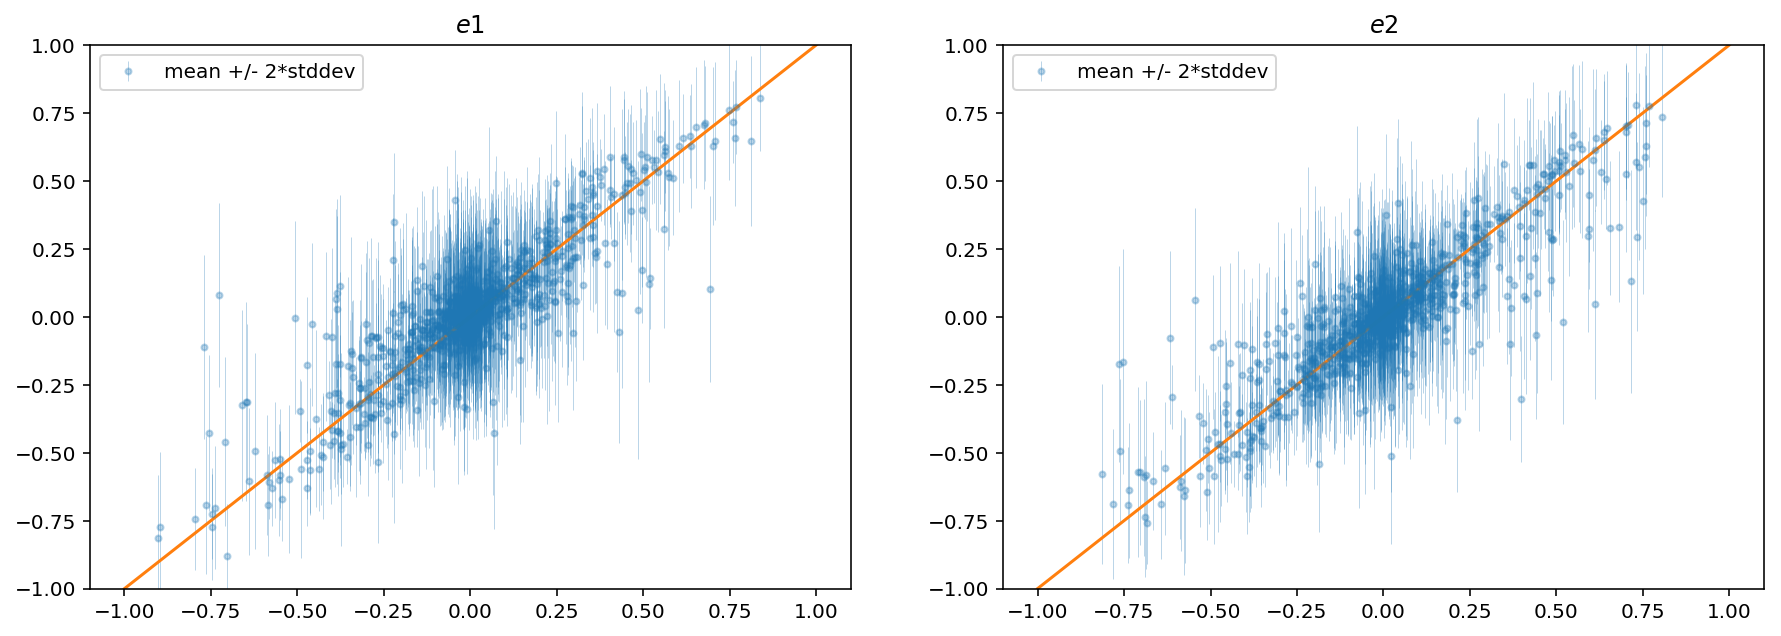

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(-e1[:nb_of_points], e1_out_mean, yerr = 2*e1_out_std,  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].plot(x, x)
axes[0].legend()
axes[0].set_ylim(-1,1)
axes[0].set_title('$e1$')

axes[1].errorbar(e2[:nb_of_points], e2_out_mean, yerr = 2*e2_out_std,  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[1].plot(x, x)
axes[1].legend()
axes[1].set_ylim(-1,1)
axes[1].set_title('$e2$')

Comparison with HSM measurement

In [33]:
diff_net_e1 = e1_out_mean + e1[:nb_of_points]
diff_net_e2 = e2_out_mean - e2[:nb_of_points]

diff_hsm_e1 = data['e1_hsm_regauss'][:nb_of_points] + e1[:nb_of_points]
diff_hsm_e2 = data['e2_hsm_regauss'][:nb_of_points] - e2[:nb_of_points]

Text(0, 0.5, 'ellipticity error (predict - true)')

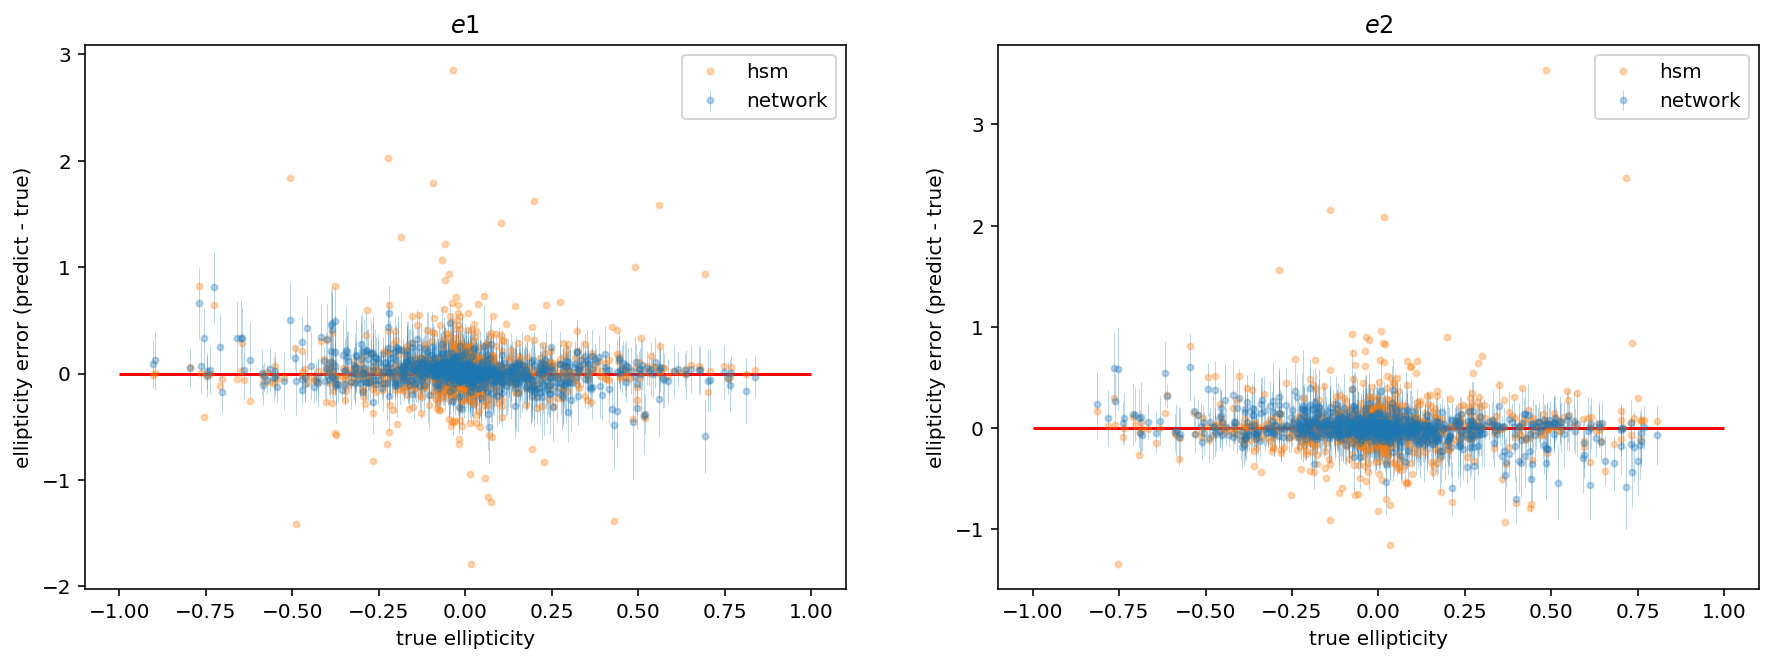

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


axes[0].errorbar(-e1[:nb_of_points], diff_net_e1, yerr = 2*e1_out_std,  fmt='.', elinewidth=0.5, label = 'network', alpha = 0.3)
axes[0].plot(-e1[:nb_of_points], diff_hsm_e1,'.', label = 'hsm', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].hlines(0,-1,1,'r')
axes[0].legend()

axes[0].set_title('$e1$')
axes[0].set_xlabel('true ellipticity')
axes[0].set_ylabel('ellipticity error (predict - true)')

axes[1].errorbar(e2[:nb_of_points], diff_net_e2, yerr = 2*e2_out_std,  fmt='.', elinewidth=0.5, label = 'network', alpha = 0.3)
axes[1].plot(e2[:nb_of_points], diff_hsm_e2,'.', label = 'hsm', alpha = 0.3)
x = np.linspace(-1,1)
axes[1].hlines(0,-1,1,'r')
axes[1].legend()

axes[1].set_title('$e2$')
axes[1].set_xlabel('true ellipticity')
axes[1].set_ylabel('ellipticity error (predict - true)')

(-1, 1)

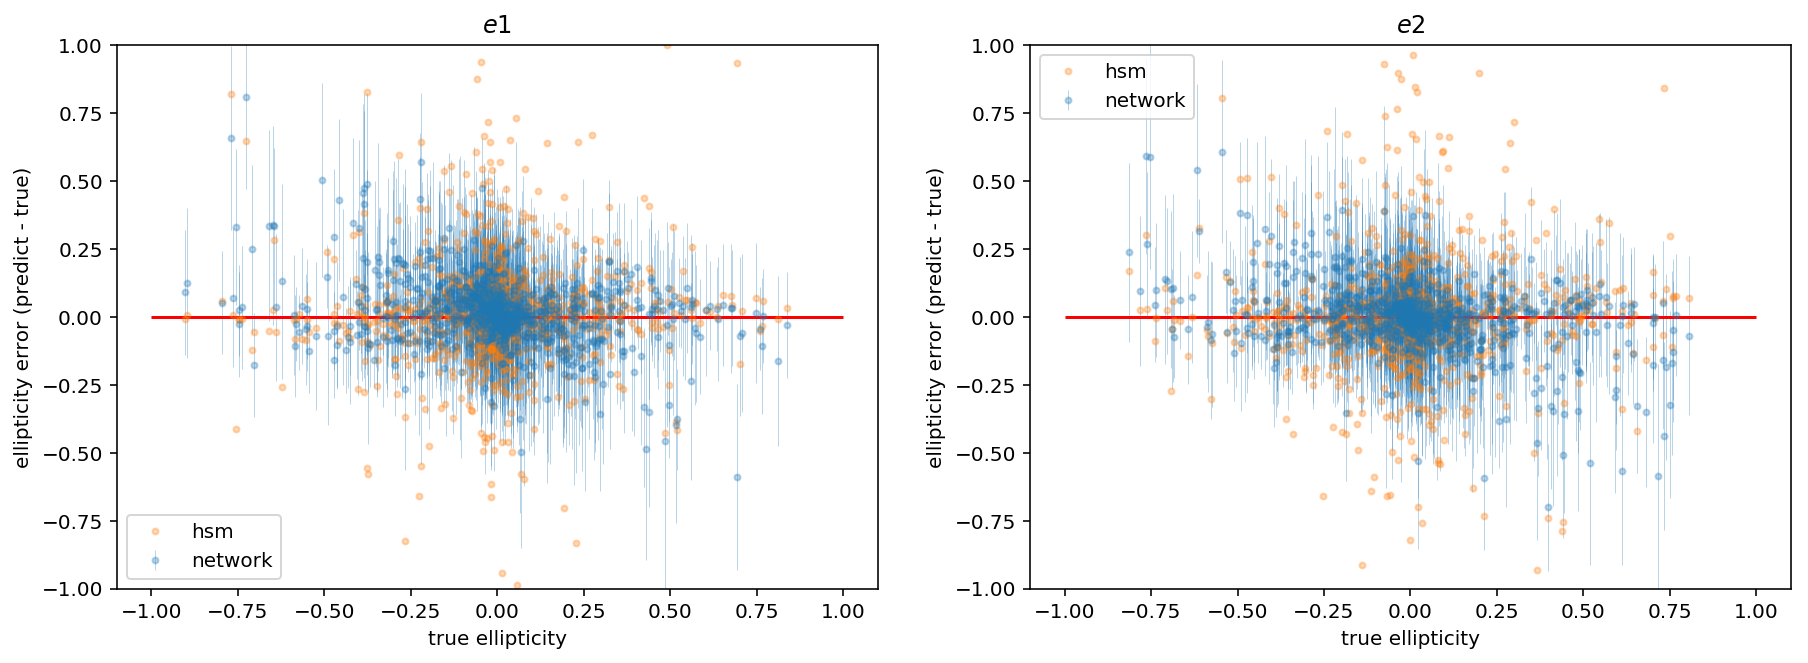

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


axes[0].errorbar(-e1[:nb_of_points], diff_net_e1, yerr = 2*e1_out_std,  fmt='.', elinewidth=0.5, label = 'network', alpha = 0.3)
axes[0].plot(-e1[:nb_of_points], diff_hsm_e1,'.', label = 'hsm', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].hlines(0,-1,1,'r')
axes[0].legend()

axes[0].set_title('$e1$')
axes[0].set_xlabel('true ellipticity')
axes[0].set_ylabel('ellipticity error (predict - true)')
axes[0].set_ylim(-1,1)

axes[1].errorbar(e2[:nb_of_points], diff_net_e2, yerr = 2*e2_out_std,  fmt='.', elinewidth=0.5, label = 'network', alpha = 0.3)
axes[1].plot(e2[:nb_of_points], diff_hsm_e2,'.', label = 'hsm', alpha = 0.3)
x = np.linspace(-1,1)
axes[1].hlines(0,-1,1,'r')
axes[1].legend()

axes[1].set_title('$e2$')
axes[1].set_xlabel('true ellipticity')
axes[1].set_ylabel('ellipticity error (predict - true)')
axes[1].set_ylim(-1,1)

(-1, 1)

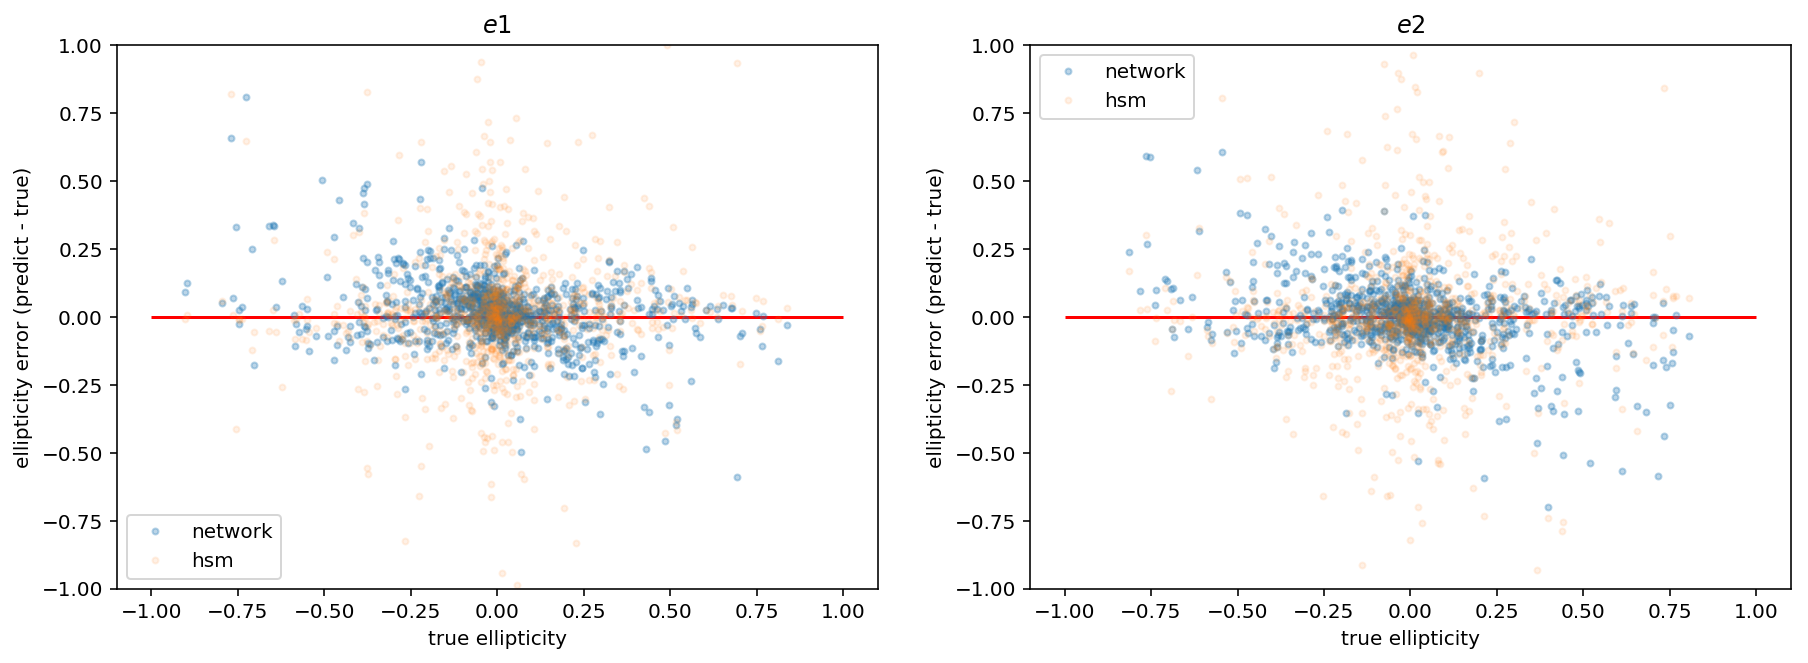

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


axes[0].plot(-e1[:nb_of_points], diff_net_e1,'.', label = 'network', alpha = 0.3)
axes[0].plot(-e1[:nb_of_points], diff_hsm_e1,'.', label = 'hsm', alpha = 0.1)
x = np.linspace(-1,1)
axes[0].hlines(0,-1,1,'r')
axes[0].legend()

axes[0].set_title('$e1$')
axes[0].set_xlabel('true ellipticity')
axes[0].set_ylabel('ellipticity error (predict - true)')
axes[0].set_ylim(-1,1)

axes[1].plot(e2[:nb_of_points], diff_net_e2, '.', label = 'network', alpha = 0.3)
axes[1].plot(e2[:nb_of_points], diff_hsm_e2,'.', label = 'hsm', alpha = 0.1)
x = np.linspace(-1,1)
axes[1].hlines(0,-1,1,'r')
axes[1].legend()

axes[1].set_title('$e2$')
axes[1].set_xlabel('true ellipticity')
axes[1].set_ylabel('ellipticity error (predict - true)')
axes[1].set_ylim(-1,1)

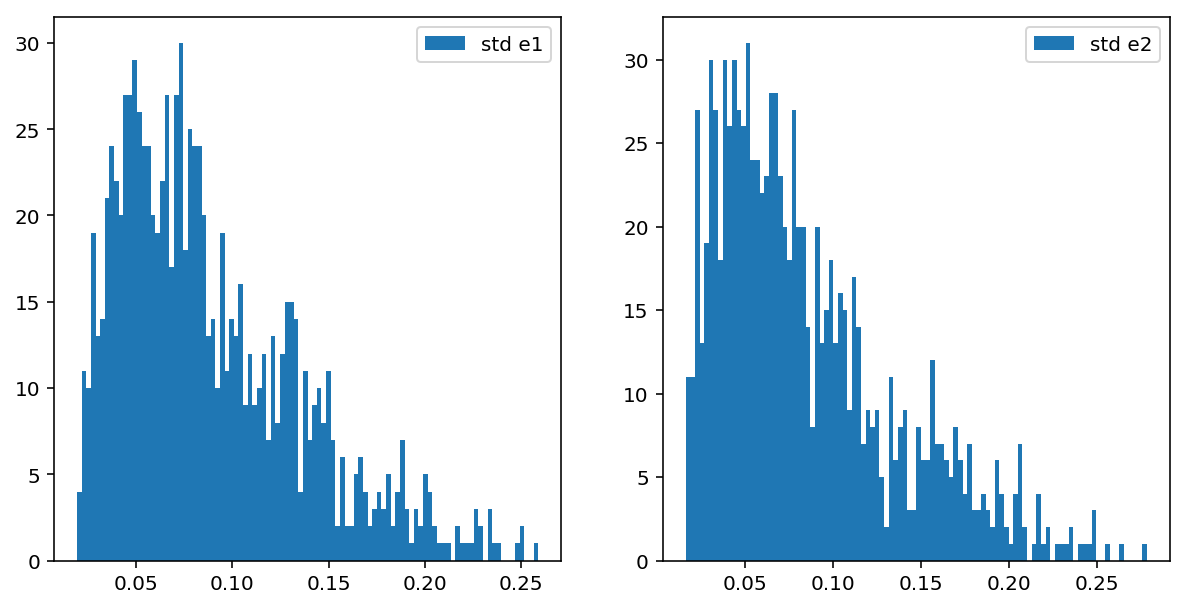

In [39]:
fig, ax = plt.subplots(1,2,figsize = (10,5))
_ = ax[0].hist(e1_out_std, bins = 100, label = 'std e1')
_ = ax[1].hist(e2_out_std, bins = 100, label = 'std e2')
ax[0].legend()
ax[1].legend()

## Model v2 (magnitude cut at 26.5 in $r$-band)

### Load data

In [12]:
images = np.load(root_dir_v2+'img_sample.npy', mmap_mode = 'c')
psf = np.load(root_dir_v2+'psf_sample.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v2+'img_data.csv')

ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])

ellipticity_1 = calc_lensed_ellipticity_1(ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity_2 = calc_lensed_ellipticity_2(ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity   = calc_lensed_ellipticity(ell_1, ell_2, shear_1, shear_2, convergence)

ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

e1 = ellipticity_conversion(ellipticity_1)
e2 = ellipticity_conversion(ellipticity_2)

### Load models

In [13]:
latest = tf.train.latest_checkpoint(dir_model_v2)
net.load_weights(latest)

In [14]:
nb_of_points = 1000
output_v2 = net([tf.cast(images[:nb_of_points], tf.float32), tf.cast(psf[:nb_of_points], tf.float32)])

e1_out_mean_v2 = K.get_value(output_v2.mean())[:,0]
e2_out_mean_v2 = K.get_value(output_v2.mean())[:,1]

e1_out_std_v2 = K.get_value(output_v2.stddev())[:,0]
e2_out_std_v2 = K.get_value(output_v2.stddev())[:,1]

In [50]:
#e1_out_mean_v2 = quantile_transformer_1.inverse_transform(e1_out_mean_v2.reshape(-1, 1))
#e2_out_mean_v2 = quantile_transformer_2.inverse_transform(e2_out_mean_v2.reshape(-1, 1))

#e1_out_std_v2 = quantile_transformer_1.inverse_transform(e1_out_std_v2.reshape(-1, 1))
#e2_out_std_v2 = quantile_transformer_2.inverse_transform(e2_out_std_v2.reshape(-1, 1))

In [19]:
diff_net_e1_v2 = e1_out_mean_v2 + e1[:nb_of_points]
diff_net_e2_v2 = e2_out_mean_v2 - e2[:nb_of_points]

diff_hsm_e1_v2 = data['e1_hsm_regauss'][:nb_of_points] + e1[:nb_of_points]
diff_hsm_e2_v2 = data['e2_hsm_regauss'][:nb_of_points] - e2[:nb_of_points]

(-1.5, 1.5)

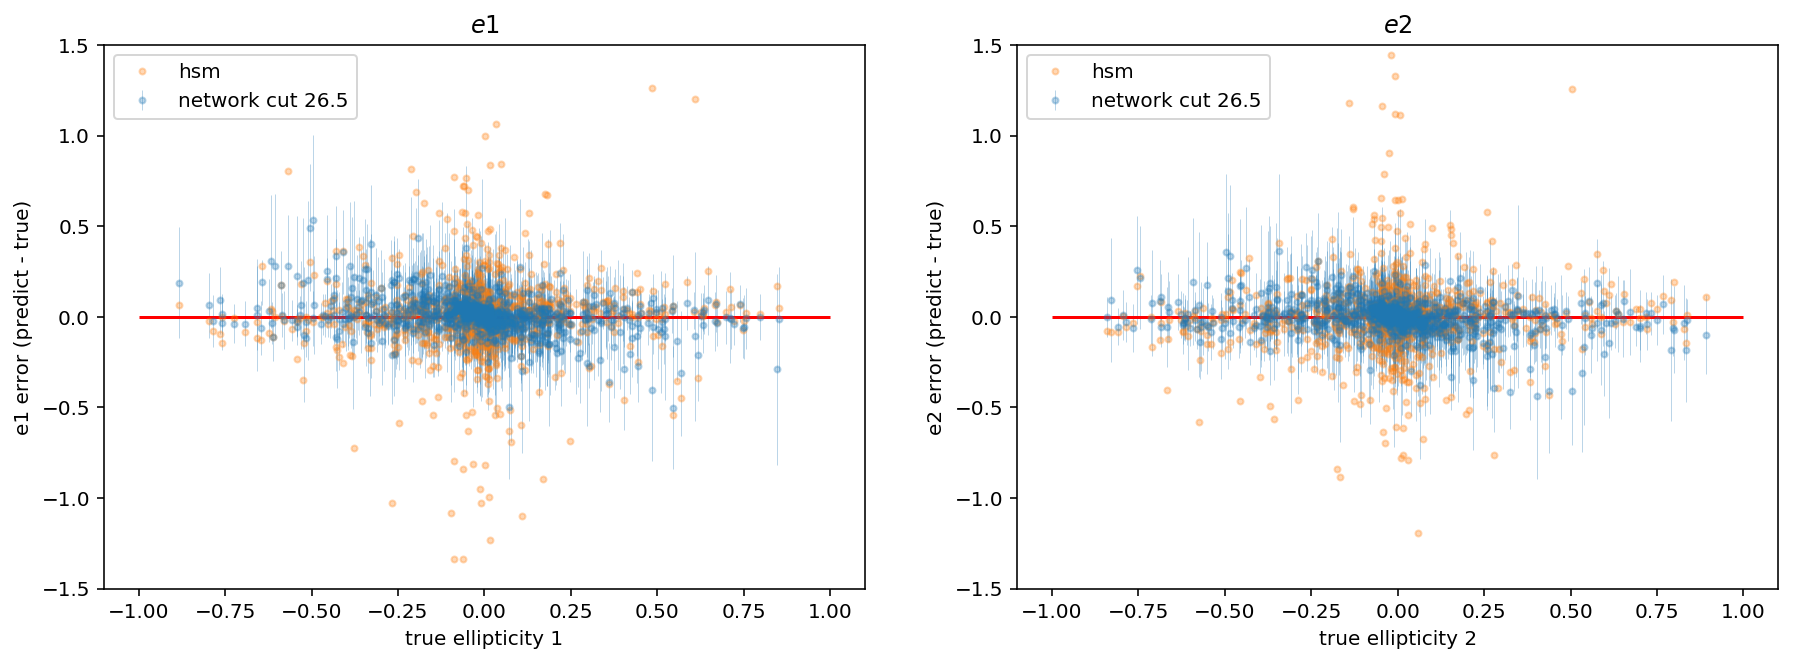

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


axes[0].errorbar(-e1[:nb_of_points], diff_net_e1_v2, yerr = 2*e1_out_std_v2,  fmt='.', elinewidth=0.5, label = 'network cut 26.5', alpha = 0.3)
axes[0].plot(-e1[:nb_of_points], diff_hsm_e1_v2,'.', label = 'hsm', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].hlines(0,-1,1,'r')
axes[0].legend()
#axes[0].set_ylim(-0.2,0.2)
axes[0].set_title('$e1$')
axes[0].set_xlabel('true ellipticity 1')
axes[0].set_ylabel('e1 error (predict - true)')
axes[0].set_ylim(-1.5,1.5)

axes[1].errorbar(e2[:nb_of_points], diff_net_e2_v2, yerr = 2*e2_out_std_v2,  fmt='.', elinewidth=0.5, label = 'network cut 26.5', alpha = 0.3)
axes[1].plot(e2[:nb_of_points], diff_hsm_e2_v2,'.', label = 'hsm', alpha = 0.3)
x = np.linspace(-1,1)
axes[1].hlines(0,-1,1,'r')
axes[1].legend()
#nb_of_pointsaxes[1].set_ylim(-0.2,0.2)
axes[1].set_title('$e2$')
axes[1].set_xlabel('true ellipticity 2')
axes[1].set_ylabel('e2 error (predict - true)')
axes[1].set_ylim(-1.5,1.5)

(-0.5, 0.5)

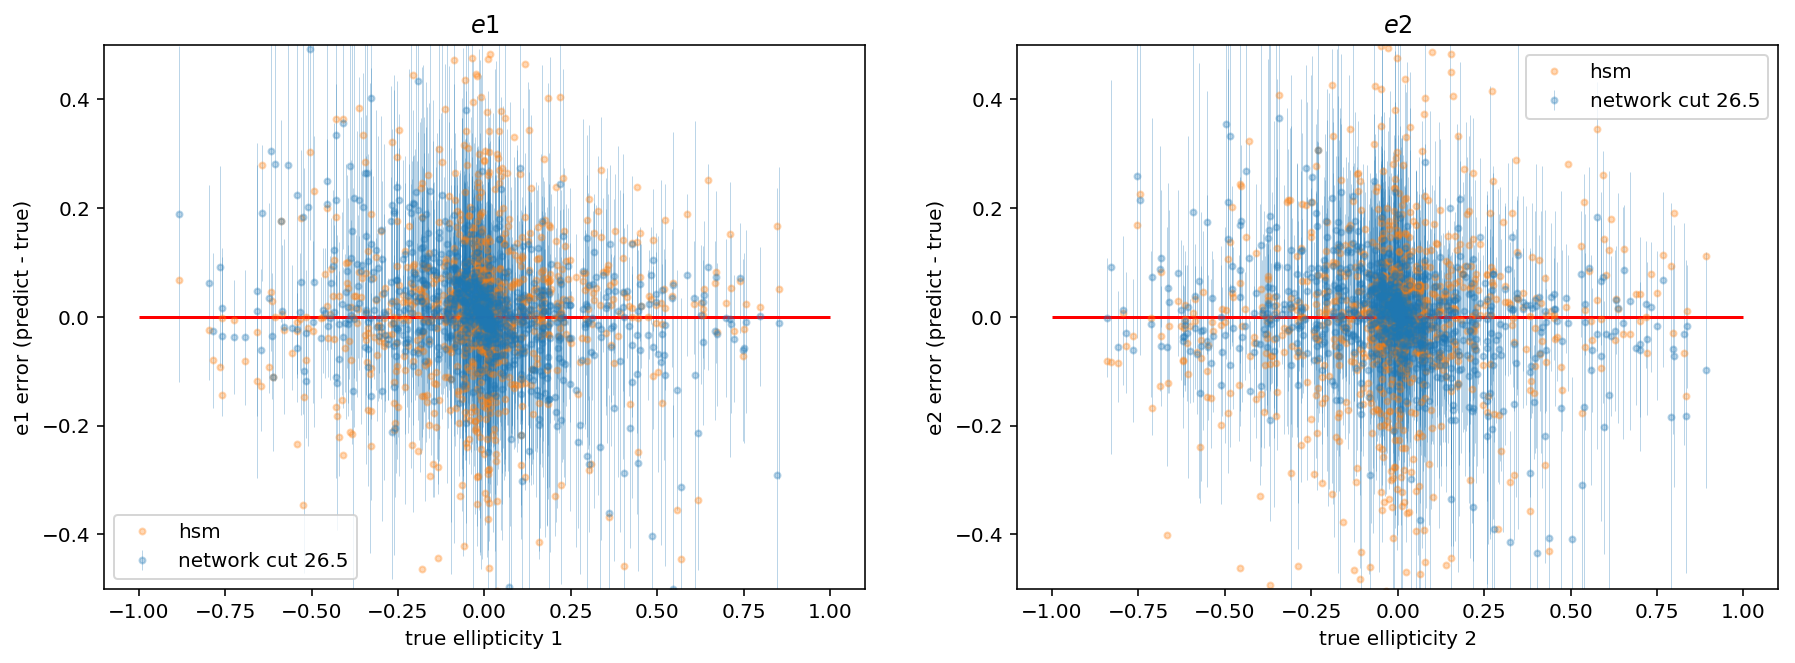

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


axes[0].errorbar(-e1[:nb_of_points], diff_net_e1_v2, yerr = 2*e1_out_std_v2,  fmt='.', elinewidth=0.5, label = 'network cut 26.5', alpha = 0.3)
axes[0].plot(-e1[:nb_of_points], diff_hsm_e1_v2,'.', label = 'hsm', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].hlines(0,-1,1,'r')
axes[0].legend()
#axes[0].set_ylim(-0.2,0.2)
axes[0].set_title('$e1$')
axes[0].set_xlabel('true ellipticity 1')
axes[0].set_ylabel('e1 error (predict - true)')
axes[0].set_ylim(-0.5,0.5)

axes[1].errorbar(e2[:nb_of_points], diff_net_e2_v2, yerr = 2*e2_out_std_v2,  fmt='.', elinewidth=0.5, label = 'network cut 26.5', alpha = 0.3)
axes[1].plot(e2[:nb_of_points], diff_hsm_e2_v2,'.', label = 'hsm', alpha = 0.3)
x = np.linspace(-1,1)
axes[1].hlines(0,-1,1,'r')
axes[1].legend()
#nb_of_pointsaxes[1].set_ylim(-0.2,0.2)
axes[1].set_title('$e2$')
axes[1].set_xlabel('true ellipticity 2')
axes[1].set_ylabel('e2 error (predict - true)')
axes[1].set_ylim(-0.5,0.5)

## Comparison between the two cuts on 26.5 mag cut sample

In [40]:
nb_of_points = 1000
output_v1 = net([tf.cast(images[:nb_of_points], tf.float32), tf.cast(psf[:nb_of_points], tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

diff_net_e1 = e1_out_mean + e1[:nb_of_points]
diff_net_e2 = e2_out_mean - e2[:nb_of_points]

diff_hsm_e1 = data['e1_hsm_regauss'][:nb_of_points] + e1[:nb_of_points]
diff_hsm_e2 = data['e2_hsm_regauss'][:nb_of_points] - e2[:nb_of_points]

In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
id                10000 non-null int64
e1                10000 non-null float64
e2                10000 non-null float64
shear_1           10000 non-null float64
shear_2           10000 non-null float64
redshift          10000 non-null float64
redshift_true     10000 non-null float64
blendedness       10000 non-null float64
snr_r             9996 non-null float64
convergence       10000 non-null float64
e1_hsm_regauss    9978 non-null float64
e2_hsm_regauss    9978 non-null float64
mag_r_meas        9996 non-null float64
mag_r_true        10000 non-null float64
dtypes: float64(13), int64(1)
memory usage: 1.1 MB


Text(0, 0.5, 'e2 error (predict - true)')

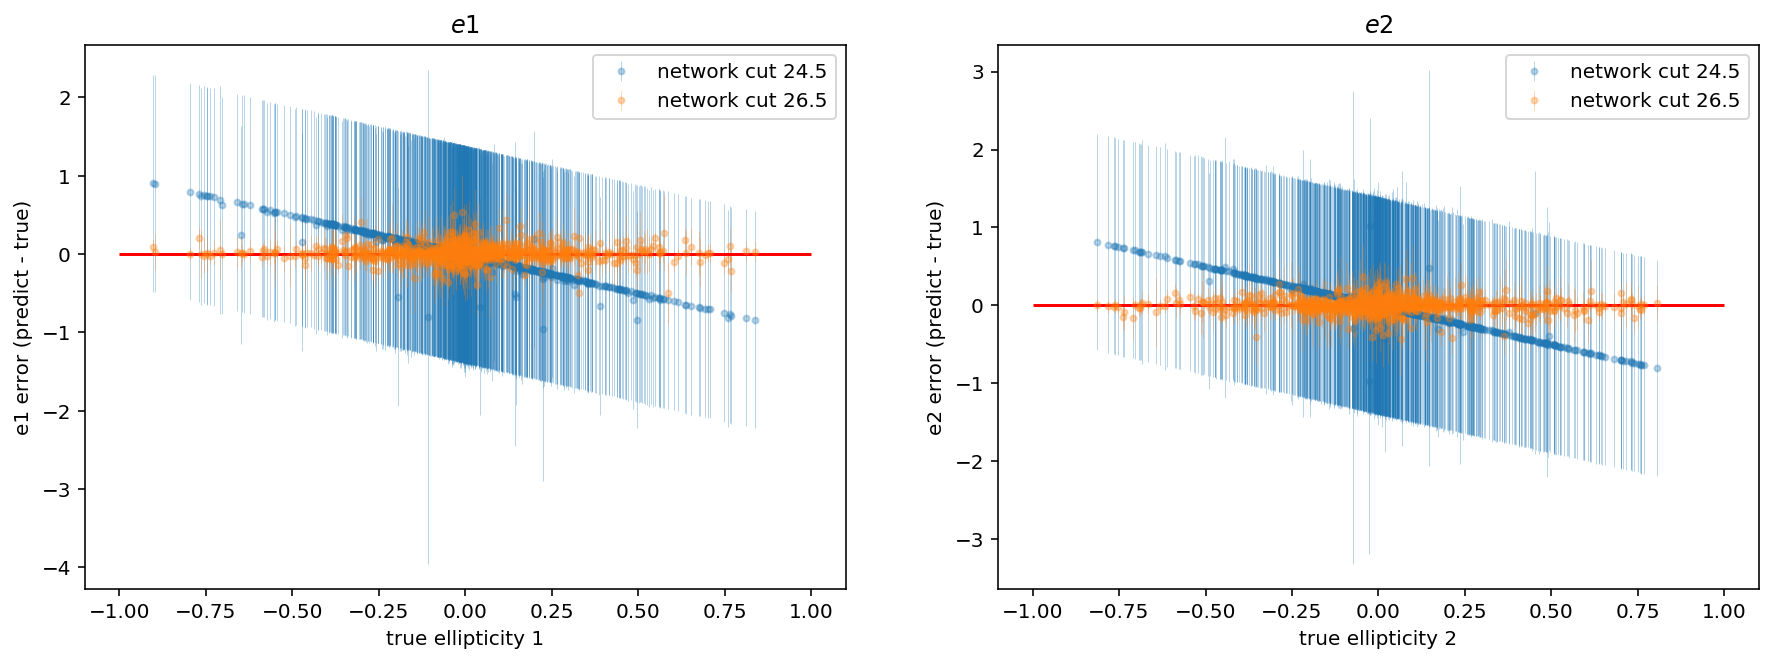

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(-e1[:nb_of_points], diff_net_e1, yerr = 2*e1_out_std,  fmt='.', elinewidth=0.5, label = 'network cut 24.5', alpha = 0.3)
axes[0].errorbar(-e1[:nb_of_points], diff_net_e1_v2, yerr = 2*e1_out_std_v2,  fmt='.', elinewidth=0.5, label = 'network cut 26.5', alpha = 0.3)
#axes[0].plot(-e1[:nb_of_points], diff_hsm_e1_v2,'.', label = 'hsm')
x = np.linspace(-1,1)
axes[0].hlines(0,-1,1,'r')
axes[0].legend()
#axes[0].set_ylim(-0.2,0.2)
axes[0].set_title('$e1$')
axes[0].set_xlabel('true ellipticity 1')
axes[0].set_ylabel('e1 error (predict - true)')

axes[1].errorbar(e2[:nb_of_points], diff_net_e2, yerr = 2*e2_out_std,  fmt='.', elinewidth=0.5, label = 'network cut 24.5', alpha = 0.3)
axes[1].errorbar(e2[:nb_of_points], diff_net_e2_v2, yerr = 2*e2_out_std_v2,  fmt='.', elinewidth=0.5, label = 'network cut 26.5', alpha = 0.3)

x = np.linspace(-1,1)
axes[1].hlines(0,-1,1,'r')
axes[1].legend()
#nb_of_pointsaxes[1].set_ylim(-0.2,0.2)
axes[1].set_title('$e2$')
axes[1].set_xlabel('true ellipticity 2')
axes[1].set_ylabel('e2 error (predict - true)')

In [ ]:
data['exp'] = nb_of_points*['']

In [ ]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(data, 
              x = 'mag_r_true', y = 'e_error', z = 'exp',
              xlim = (15, 1000),
              ylim = (-0.32, 0.32), 
              ylim2 = (-0.035, 0.035), 
              x_scale = 'log',
              legend = ['LSST $ugrizy$', 'LSST + Euclid'],
              x_label='Signal to noise ratio S/N', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(S/N)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)

In [ ]:
e2_out_std

## Which images are problematic

### For HSM

In [39]:
lim = 0.3

pb_idx = np.where((diff_hsm_e1_v2>lim) | (diff_hsm_e1_v2<-lim) | (diff_hsm_e2_v2>lim) | (diff_hsm_e2_v2<-lim))[0]

In [41]:
print(len(pb_idx))
print(pb_idx)

204
[  5   7  16  22  25  35  39  43  46  55  62  65  70  71  74  83  86  92
 110 116 117 121 123 124 131 137 142 143 148 156 162 163 167 179 195 198
 202 226 228 233 234 241 247 250 257 264 266 281 283 284 285 286 298 305
 314 317 318 322 327 330 332 333 334 337 341 349 351 367 369 371 373 385
 389 391 395 397 400 401 405 406 410 411 415 416 424 429 431 436 438 445
 446 450 452 457 461 468 474 477 483 492 496 500 508 513 529 533 536 543
 544 545 546 554 563 573 576 579 588 600 611 618 623 626 637 639 643 645
 648 651 653 659 660 661 667 668 678 686 699 700 702 703 705 708 718 720
 727 729 734 739 764 766 770 775 776 778 781 786 791 809 814 822 825 830
 832 838 842 846 848 851 866 867 868 869 875 880 881 883 884 898 902 903
 905 906 909 914 917 919 925 933 934 937 945 952 953 960 967 968 978 980
 981 988 990 991 992 993]


Is there a higher mean blendedness for the images problematic for HSM REGAUSS method ?

In [43]:
print('mean blendedness of sample with high error: '+str(np.mean((data['blendedness'][pb_idx],data['blendedness'][pb_idx]))))
print('mean blendedness of whole sample: '+str(np.mean(data['blendedness'])))

mean blendedness of sample with high error: 0.032739697984638785
mean blendedness of whole sample: 0.020072220179457645


This difference might partially explain the gap between our method and HSM REGAUSS

Let's check other possibilities (mag, redshift, snr... ?)

In [44]:
# Magnitudes
print('mean magnitudes of sample with high error: '+str(np.mean((data['mag_r_meas'][pb_idx],data['mag_r_meas'][pb_idx]))))
print('mean magnitudes of whole sample: '+str(np.mean(data['mag_r_meas'])))

mean magnitudes of sample with high error: 23.743265280751466
mean magnitudes of whole sample: 23.030830373118842


In [45]:
# SNR
print('mean SNR of sample with high error: '+str(np.mean((data['snr_r'][pb_idx],data['snr_r'][pb_idx]))))
print('mean SNR of whole sample: '+str(np.mean(data['snr_r'])))

mean SNR of sample with high error: 74.93792134076388
mean SNR of whole sample: 176.78466416572687


In [46]:
# redshift
print('mean redshift of sample with high error: '+str(np.mean((data['redshift'][pb_idx],data['redshift'][pb_idx]))))
print('mean redshift of whole sample: '+str(np.mean(data['redshift'])))

mean redshift of sample with high error: 0.9261371267268508
mean redshift of whole sample: 0.7607052269240994


Higher magnitude and reshift, and consequently lower SNR seem to be also an aggraving factor for HSM REGAUSS

Let's plot some of these images

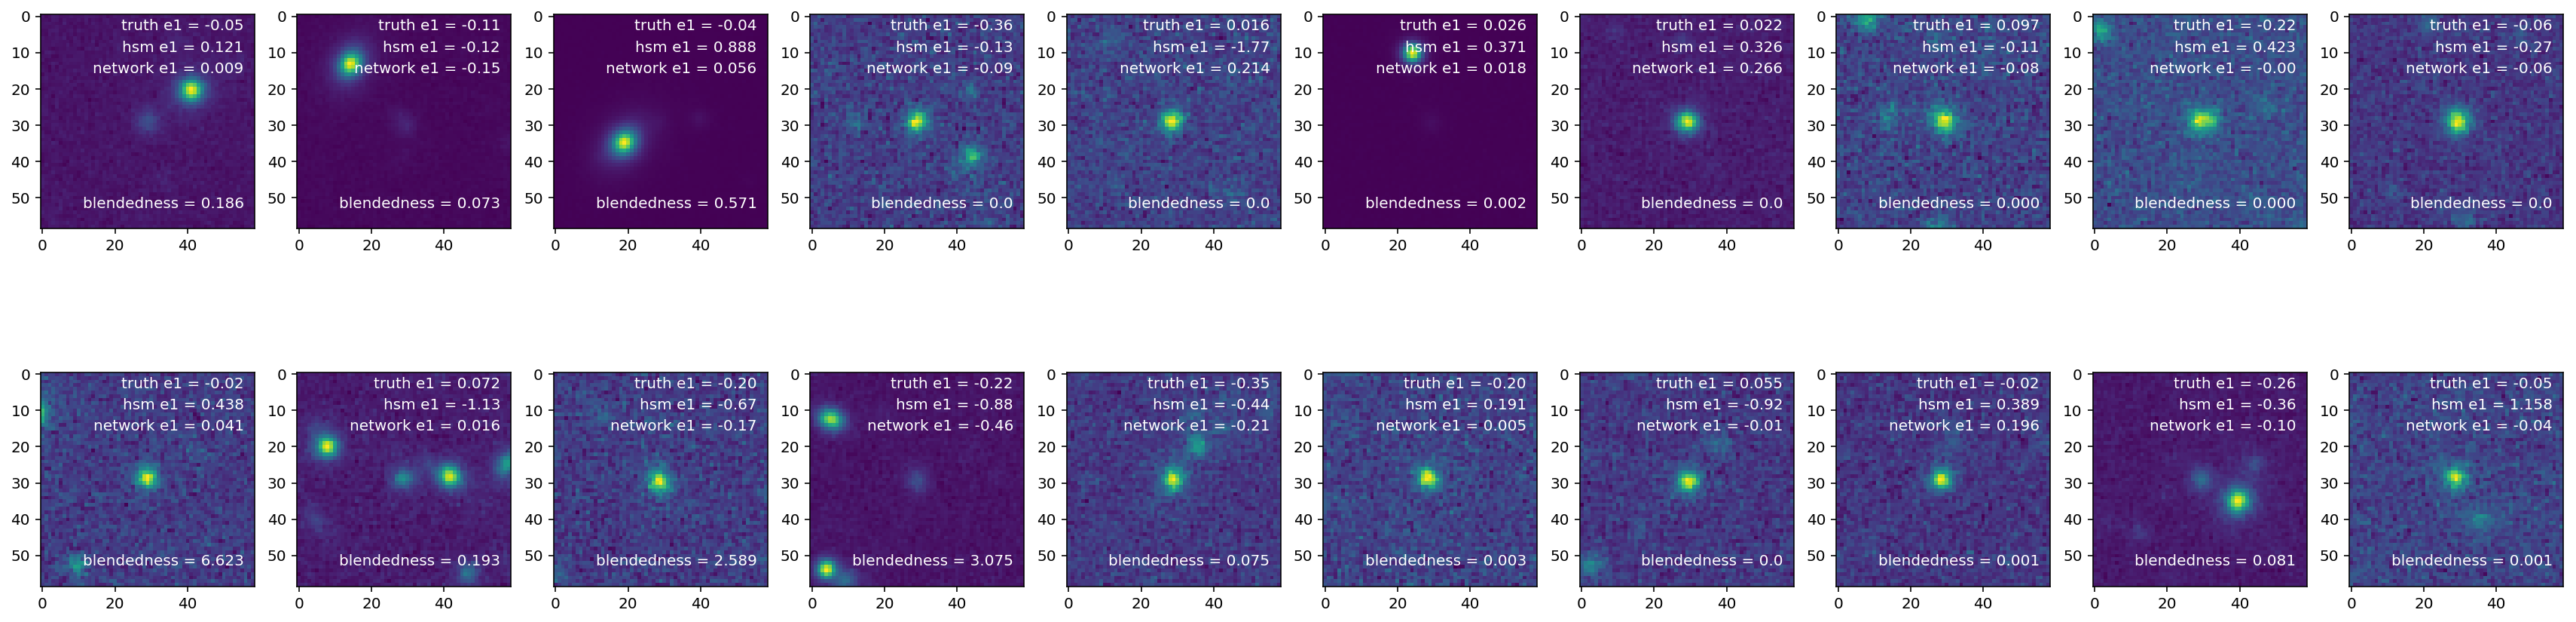

In [93]:
fig, axes = plt.subplots(2, 10, figsize=(30,8))
left, width = .15, .80
bottom, height = .15, .83
right = left + width
top = bottom + height

for i in range(2):
    for j in range (10):
        k = np.random.choice(pb_idx)
        axes[i,j].imshow(images[k,:,:,2])
        axes[i,j].text(right, top, 'truth e1 = '+str(-e1[k])[:5], horizontalalignment='right', verticalalignment='top', color = 'white', transform=axes[i,j].transAxes)
        axes[i,j].text(right, top-0.1, 'hsm e1 = '+str(data['e1_hsm_regauss'][k])[:5], horizontalalignment='right', verticalalignment='top', color = 'white', transform=axes[i,j].transAxes)
        axes[i,j].text(right, top-0.2, 'network e1 = '+str(e1_out_mean[:,0][k])[:5], horizontalalignment='right', verticalalignment='top', color = 'white', transform=axes[i,j].transAxes)
        axes[i,j].text(right, bottom, 'blendedness = '+str(data['blendedness'][k])[:5], horizontalalignment='right', verticalalignment='top', color = 'white', transform=axes[i,j].transAxes)

Now let's see how our network behaves on these particular cases compared to HSM

mean error e1 for HSM: 0.10934042630443055
mean error e1 for network: 0.03983952248960277
mean error e2 for HSM: 0.07757291877271431
mean error e2 for network: 0.015068948161050017


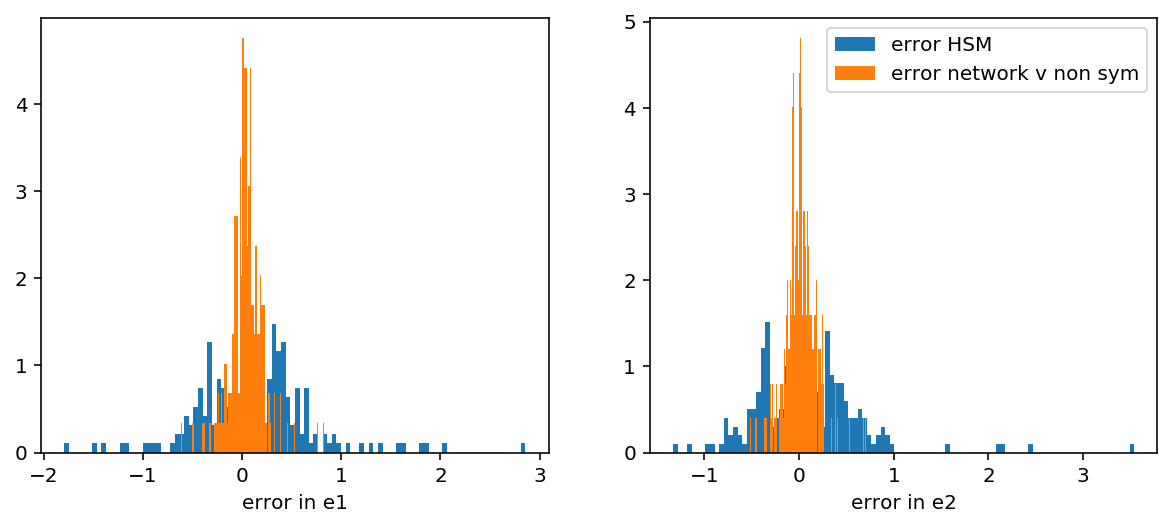

In [50]:
fig, axes = plt.subplots(1,2,figsize = (10,4))

_ = axes[0].hist(diff_hsm_e1_v2[pb_idx], bins =100, normed = True, label = 'error HSM')
_ = axes[0].hist(diff_net_e1[pb_idx], bins =100, normed = True, label = 'error network v non sym')

_ = axes[1].hist(diff_hsm_e2_v2[pb_idx], bins =100, normed = True, label = 'error HSM')
_ = axes[1].hist(diff_net_e2[pb_idx], bins =100, normed = True, label = 'error network v non sym')

axes[0].set_xlabel('error in e1')
axes[1].set_xlabel('error in e2')

plt.legend()

print('mean error e1 for HSM: '+str(np.mean(diff_hsm_e1_v2[pb_idx])))
print('mean error e1 for network: '+str(np.mean(diff_net_e1[pb_idx])))

print('mean error e2 for HSM: '+str(np.mean(diff_hsm_e2_v2[pb_idx])))
print('mean error e2 for network: '+str(np.mean(diff_net_e2[pb_idx])))

### For our methods

In [62]:
lim = 0.2

pb_idx_net = np.where((diff_net_e1>lim) | (diff_net_e1<-lim) | (diff_net_e2>lim) | (diff_net_e2<-lim))[0]
pb_idx_net_v2 = np.where((diff_net_e1_v2>lim) | (diff_net_e1_v2<-lim) | (diff_net_e2_v2>lim) | (diff_net_e2_v2<-lim))[0]

In [63]:
pb_idx_net

array([ 14,  16,  22,  43,  92,  96, 115, 124, 136, 162, 184, 188, 197,
       202, 217, 228, 234, 241, 257, 264, 273, 281, 282, 283, 284, 285,
       289, 317, 322, 341, 344, 349, 365, 373, 391, 397, 400, 401, 405,
       411, 415, 446, 450, 451, 466, 472, 475, 508, 528, 531, 543, 545,
       556, 574, 600, 607, 615, 618, 620, 623, 626, 648, 705, 718, 727,
       734, 739, 820, 830, 832, 835, 838, 839, 848, 863, 875, 898, 906,
       909, 917, 924, 925, 937, 953, 960, 981, 987, 994, 996, 998])

In [64]:
pb_idx_net_v2

array([ 22,  43,  65,  74,  96, 103, 115, 116, 123, 124, 136, 142, 156,
       162, 192, 197, 201, 202, 210, 217, 228, 229, 234, 241, 257, 264,
       273, 281, 283, 284, 285, 317, 322, 341, 344, 349, 373, 389, 391,
       397, 410, 411, 415, 432, 446, 450, 451, 461, 466, 468, 472, 481,
       492, 497, 501, 528, 543, 544, 545, 556, 600, 607, 611, 615, 618,
       620, 623, 626, 628, 635, 643, 647, 661, 670, 672, 698, 705, 718,
       723, 727, 734, 764, 776, 827, 830, 832, 838, 839, 848, 863, 867,
       868, 869, 875, 898, 906, 909, 917, 924, 925, 937, 945, 953, 957,
       960, 977, 987, 992, 994, 996])

For non symetric inputs version

In [65]:
# Blendedness
print('mean blendedness of sample with high error: '+str(np.mean((data['blendedness'][pb_idx_net],data['blendedness'][pb_idx_net]))))
print('mean blendedness of whole sample: '+str(np.mean(data['blendedness'])))

# Magnitudes
print('mean magnitudes of sample with high error: '+str(np.mean((data['mag_r_meas'][pb_idx_net],data['mag_r_meas'][pb_idx_net]))))
print('mean magnitudes of whole sample: '+str(np.mean(data['mag_r_meas'])))

# SNR
print('mean SNR of sample with high error: '+str(np.mean((data['snr_r'][pb_idx_net],data['snr_r'][pb_idx_net]))))
print('mean SNR of whole sample: '+str(np.mean(data['snr_r'])))

# redshift
print('mean redshift of sample with high error: '+str(np.mean((data['redshift'][pb_idx_net],data['redshift'][pb_idx_net]))))
print('mean redshift of whole sample: '+str(np.mean(data['redshift'])))

mean blendedness of sample with high error: 0.032275444810458125
mean blendedness of whole sample: 0.020072220179457645
mean magnitudes of sample with high error: 23.726734759001193
mean magnitudes of whole sample: 23.030830373118842
mean SNR of sample with high error: 135.62698348478406
mean SNR of whole sample: 176.78466416572687
mean redshift of sample with high error: 0.8045908947502192
mean redshift of whole sample: 0.7607052269240994


For symetric inputs version

In [66]:
# Blendedness
print('mean blendedness of sample with high error: '+str(np.mean((data['blendedness'][pb_idx_net_v2],data['blendedness'][pb_idx_net_v2]))))
print('mean blendedness of whole sample: '+str(np.mean(data['blendedness'])))

# Magnitudes
print('mean magnitudes of sample with high error: '+str(np.mean((data['mag_r_meas'][pb_idx_net_v2],data['mag_r_meas'][pb_idx_net_v2]))))
print('mean magnitudes of whole sample: '+str(np.mean(data['mag_r_meas'])))

# SNR
print('mean SNR of sample with high error: '+str(np.mean((data['snr_r'][pb_idx_net_v2],data['snr_r'][pb_idx_net_v2]))))
print('mean SNR of whole sample: '+str(np.mean(data['snr_r'])))

# redshift
print('mean redshift of sample with high error: '+str(np.mean((data['redshift'][pb_idx_net_v2],data['redshift'][pb_idx_net_v2]))))
print('mean redshift of whole sample: '+str(np.mean(data['redshift'])))

mean blendedness of sample with high error: 0.029789594404217967
mean blendedness of whole sample: 0.020072220179457645
mean magnitudes of sample with high error: 23.605811924307528
mean magnitudes of whole sample: 23.030830373118842
mean SNR of sample with high error: 138.09151160719156
mean SNR of whole sample: 176.78466416572687
mean redshift of sample with high error: 0.8445140875229763
mean redshift of whole sample: 0.7607052269240994


<b>Once again, its seems that it is blendedness, SNR and redshift that have an high impact on our results. It seems that the network trained with non-symetric inputs yields slightly more blendedness-agnostic results (to be confirmed). Also our methods seem much more SNR-agnostic than HSM REGAUSS. </b>